# 03 Modeling SARIMAX — Forecast Test (2016–2025)

---
## Setup & Load Data Bulanan

Membaca hasil agregasi bulanan dari `dataset/monthly_aggregated.csv` (dihasilkan oleh notebook **02 Feature Engineering**).

In [27]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')


In [28]:
# Konstanta kolom (sesuai notebook 01/02)
COL_TEMP_2M_MEAN = 'temperature_2m_mean'
COL_PRECIPITATION_SUM = 'precipitation_sum'
COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean'
COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean'
COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean'
COL_SUNSHINE_DURATION = 'sunshine_duration'
COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours'
COL_CLOUD_COVER_MEAN = 'cloud_cover_mean'

TARGETS = [COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM,
           COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN]
EXOG    = [COL_RELATIVE_HUMIDITY_2M_MEAN, COL_SUNSHINE_DURATION,
           COL_PRECIPITATION_HOURS_SUM, COL_CLOUD_COVER_MEAN]

TARGET_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
}

# Load data bulanan
MONTHLY_CSV_PATH = 'dataset/monthly_aggregated.csv'
df_m = pd.read_csv(MONTHLY_CSV_PATH, parse_dates=['time'], index_col='time')
df_m.index.freq = 'MS'

# Split train / test
SPLIT_DATE = '2016-01-01'
train = df_m.loc[:'2015-12-31']
test  = df_m.loc[SPLIT_DATE:]

# Standardize exogenous (fit di train)
exog_mean  = train[EXOG].mean()
exog_std   = train[EXOG].std()
exog_train = (train[EXOG] - exog_mean) / exog_std
exog_test  = (test[EXOG]  - exog_mean) / exog_std

print(f'Periode penuh : {df_m.index.min().date()} → {df_m.index.max().date()}  ({len(df_m)} bulan)')
print(f'Train         : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} bulan)')
print(f'Test          : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} bulan)')
print(f'exog_train: {exog_train.shape}   exog_test: {exog_test.shape}')
df_m.head()


Periode penuh : 1940-01-01 → 2025-12-01  (1032 bulan)
Train         : 1940-01-01 → 2015-12-01  (912 bulan)
Test          : 2016-01-01  → 2025-12-01  (120 bulan)
exog_train: (912, 4)   exog_test: (120, 4)


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean,sunshine_duration,cloud_cover_mean,precipitation_hours
time,,,,,,,,
1940-01-01,23.080000,11.686667,0.492667,24.280000,89.166667,24444.787000,96.366667,14.633333
1940-02-01,23.496552,5.834483,0.487862,24.713793,87.344828,34958.672759,88.896552,10.103448
1940-03-01,24.332258,4.167742,0.451000,25.841935,85.290323,40973.355484,75.709677,6.612903
1940-04-01,24.460000,5.283333,0.443300,26.056667,86.033333,38914.885333,66.866667,9.000000
1940-05-01,23.961290,7.435484,0.485677,25.341935,88.967742,30871.090000,87.935484,10.935484


---
## Fit SARIMAX & Forecast Test (2016–2025)

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order kandidat: (p,d,q)(P,D,Q,m)
ORDERS = {
    COL_TEMP_2M_MEAN:          ((1, 1, 4), (1, 1, 1, 12)),
    COL_PRECIPITATION_SUM:     ((0, 0, 1), (0, 1, 1, 12)),
    COL_SOIL_MOIST_0_7CM_MEAN: ((1, 1, 2), (1, 1, 1, 12)),
    COL_SOIL_TEMP_0_7CM_MEAN:  ((2, 1, 4), (2, 1, 0, 12)),
}

fits, forecasts, conf_ints = {}, {}, {}
fits_noexog, forecasts_noexog, conf_ints_noexog = {}, {}, {}
metrics = []

for col, (order, sorder) in ORDERS.items():
    # Align endog ke index exog (jaga jika exog di-diff -> kehilangan baris awal)
    y_train = train[col].loc[exog_train.index]
    y_test  = test[col].loc[exog_test.index]

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    model_without_exog = SARIMAX(
        y_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    res_noexog = model_without_exog.fit(disp=False)
    fits[col] = res
    fits_noexog[col] = res_noexog

    fc   = res.get_forecast(steps=len(y_test), exog=exog_test)
    yhat = fc.predicted_mean
    ci   = fc.conf_int(alpha=0.05)
    forecasts[col] = yhat
    conf_ints[col] = ci

    fc_ne   = res_noexog.get_forecast(steps=len(y_test))
    yhat_ne = fc_ne.predicted_mean
    ci_ne   = fc_ne.conf_int(alpha=0.05)
    forecasts_noexog[col] = yhat_ne
    conf_ints_noexog[col] = ci_ne

    rmse = np.sqrt(((y_test - yhat) ** 2).mean())
    mae  = (y_test - yhat).abs().mean()
    mape = (y_test - yhat).abs().div(y_test.abs()).mean() * 100
    metrics.append({'Target': col, 'Variant': 'with exog',
                    'order': order, 'seasonal_order': sorder,
                    'AIC': round(res.aic, 2), 'RMSE': round(rmse, 2),
                    'MAE': round(mae, 2), 'MAPE': f"{mape:.2f}%"})

    rmse_ne = np.sqrt(((y_test - yhat_ne) ** 2).mean())
    mae_ne  = (y_test - yhat_ne).abs().mean()
    mape_ne = (y_test - yhat_ne).abs().div(y_test.abs()).mean() * 100
    metrics.append({'Target': col, 'Variant': 'no exog',
                    'order': order, 'seasonal_order': sorder,
                    'AIC': round(res_noexog.aic, 2), 'RMSE': round(rmse_ne, 2),
                    'MAE': round(mae_ne, 2), 'MAPE': f"{mape_ne:.2f}%"})

display(pd.DataFrame(metrics).style.set_properties(**{'text-align': 'left'}))

,Target,Variant,order,seasonal_order,AIC,RMSE,MAE,MAPE
0,temperature_2m_mean,with exog,"(1, 1, 4)","(1, 1, 1, 12)",-258.850000,0.340000,0.270000,1.03%
1,temperature_2m_mean,no exog,"(1, 1, 4)","(1, 1, 1, 12)",791.250000,0.890000,0.740000,2.82%
2,precipitation_sum,with exog,"(0, 0, 1)","(0, 1, 1, 12)",3270.100000,1.670000,1.230000,24.70%
3,precipitation_sum,no exog,"(0, 0, 1)","(0, 1, 1, 12)",4170.630000,2.790000,2.210000,56.57%
4,soil_moisture_0_7cm_mean,with exog,"(1, 1, 2)","(1, 1, 1, 12)",-5323.570000,0.050000,0.040000,9.26%
5,soil_moisture_0_7cm_mean,no exog,"(1, 1, 2)","(1, 1, 1, 12)",-3847.650000,0.060000,0.050000,13.66%
6,soil_temperature_0_7cm_mean,with exog,"(2, 1, 4)","(2, 1, 0, 12)",656.240000,0.660000,0.530000,1.94%
7,soil_temperature_0_7cm_mean,no exog,"(2, 1, 4)","(2, 1, 0, 12)",1359.540000,1.110000,0.870000,3.13%


---
## Visualisasi Forecast vs Aktual

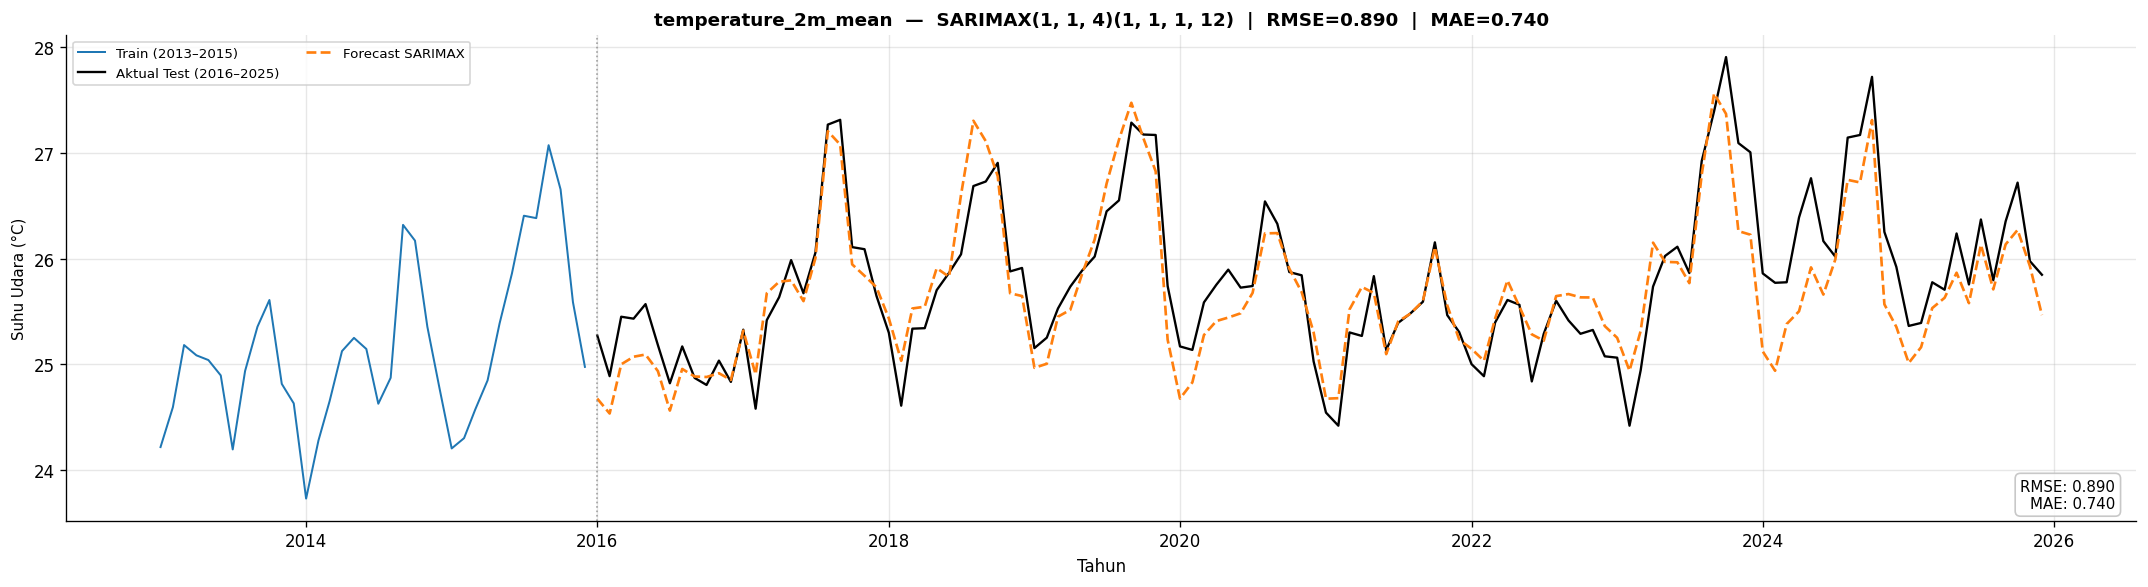

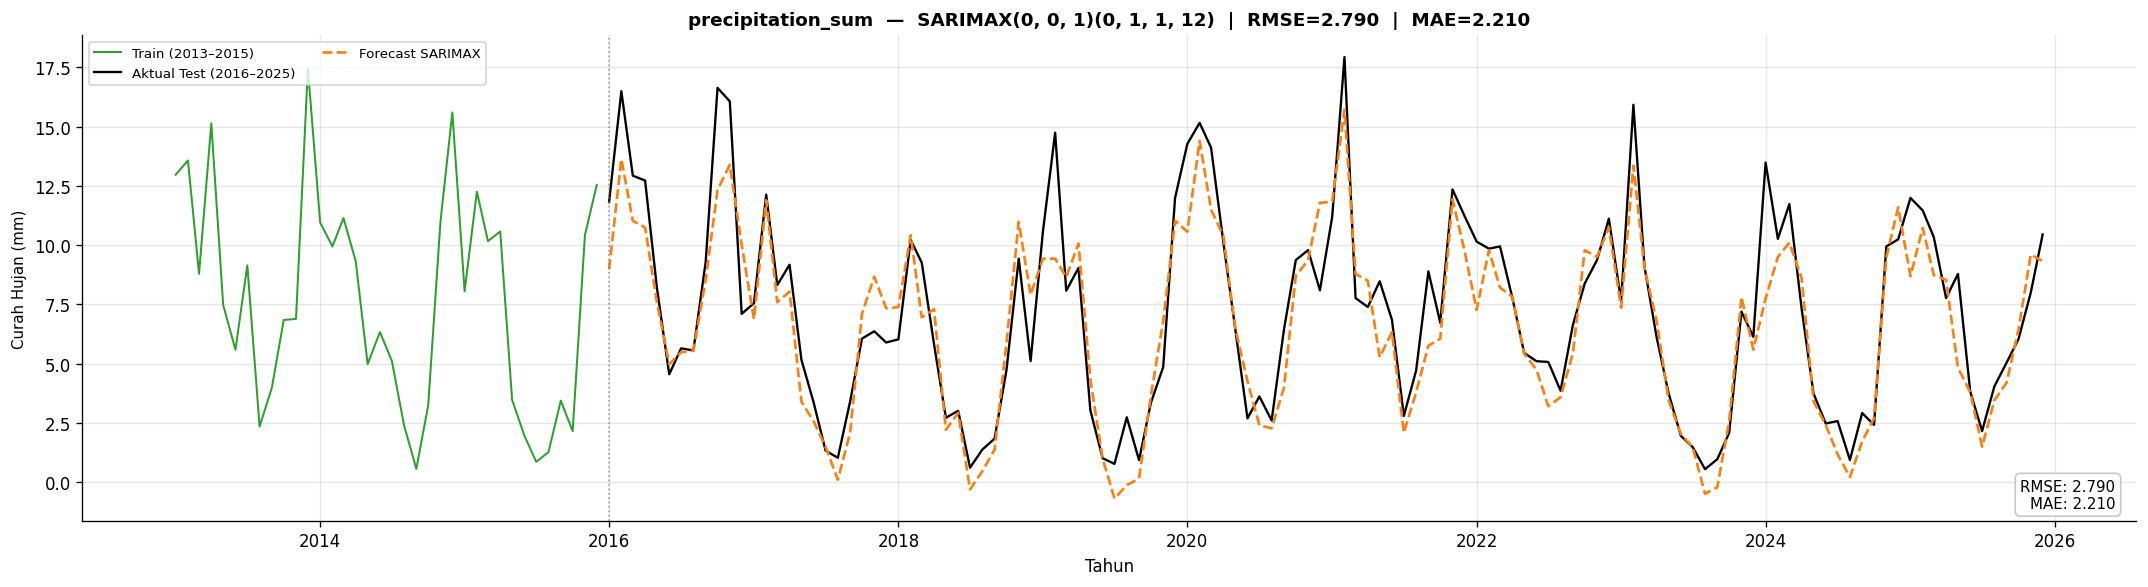

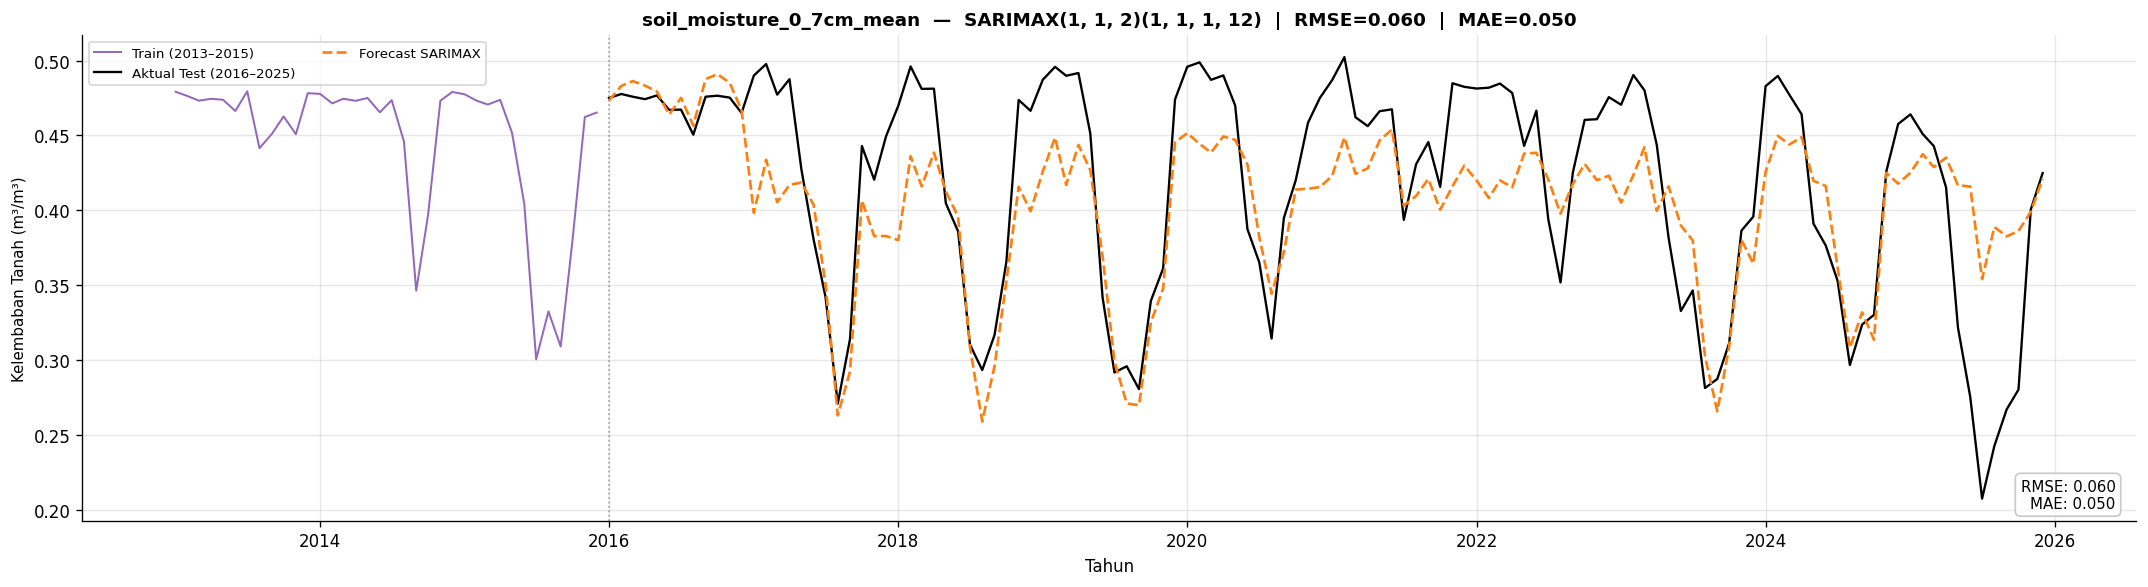

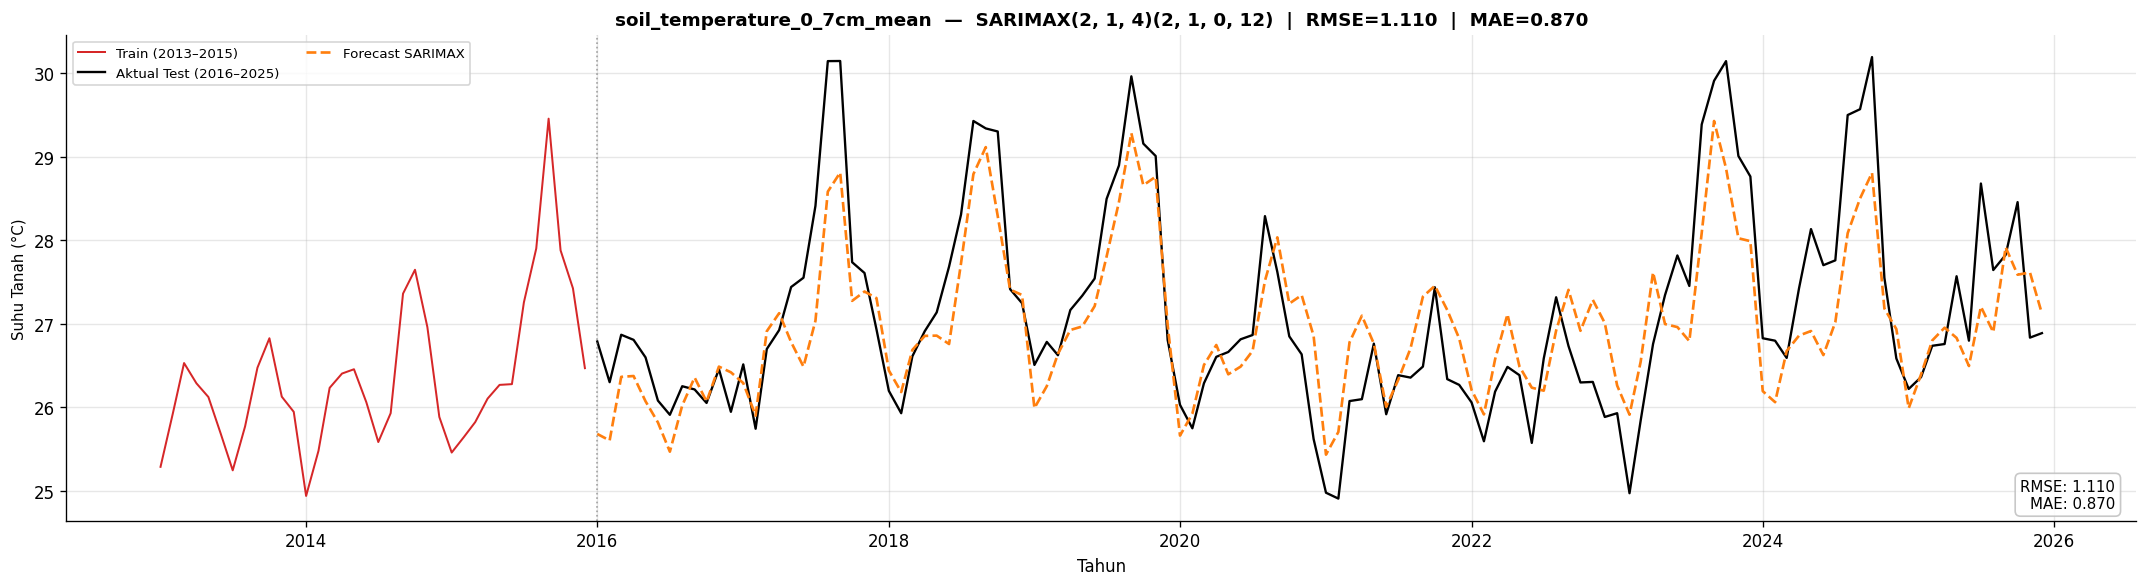

In [30]:
# Plot forecast window 2013-2025: one figure per target
PLOT_START = '2013-01-01'
plot_colors = dict(zip(TARGETS, ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']))
metrics_by_target = {m['Target']: m for m in metrics}

for col in TARGETS:
    c = plot_colors[col]
    train_win = train[col].loc[PLOT_START:]
    test_win = test[col]
    yhat = forecasts[col]
    ci = conf_ints[col]
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]

    metric_row = metrics_by_target[col]
    rmse = float(metric_row['RMSE'])
    mae = float(metric_row['MAE'])

    fig, ax = plt.subplots(figsize=(18, 5))
    ax.plot(train_win.index, train_win.values, color=c, lw=1.2, label='Train (2013–2015)')
    ax.plot(test_win.index, test_win.values, color='black', lw=1.4, label='Aktual Test (2016–2025)')
    ax.plot(yhat.index, yhat.values, color='#ff7f0e', lw=1.6, linestyle='--', label='Forecast SARIMAX')
    # ax.fill_between(yhat.index, lower.values, upper.values, color='#ff7f0e', alpha=0.15, label='95% CI')
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='gray', lw=1, linestyle=':', alpha=0.7)

    order, sorder = ORDERS[col]
    ax.set_title(f'{col}  —  SARIMAX{order}{sorder}  |  RMSE={rmse:.3f}  |  MAE={mae:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel(TARGET_LABELS[col], fontsize=9)
    ax.set_xlabel('Tahun')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    metrics_box = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}'
    ax.text(
        0.99,
        0.02,
        metrics_box,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        bbox={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'alpha': 0.85,
            'edgecolor': '0.75',
        },
    )

    plt.tight_layout()
    plt.show()